<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Day_27_Model_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,roc_auc_score,f1_score
from sklearn.metrics import matthews_corrcoef,roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
heart = fetch_openml(name="heart-statlog",version =1, as_frame=True)
X = heart.data
y = heart.target





In [10]:
y=y.map({"absent":0,"present":1}).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42,stratify=y)

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [12]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [14]:
svm = SVC(probability = True,kernel="rbf")
svm.fit(X_train, y_train)



SVC(probability=True)

In [24]:
def evaluate_model(model,name):
  pred = model.predict(X_test)
  prob = model.predict_proba(X_test)[:, 1] # Corrected to get probabilities of the positive class for all samples
  accuracy = accuracy_score(y_test,pred)
  auc = roc_auc_score(y_test,prob)
  f1 = f1_score(y_test,pred)
  mcc = matthews_corrcoef(y_test,pred)
  return [name,accuracy,auc, f1,mcc]

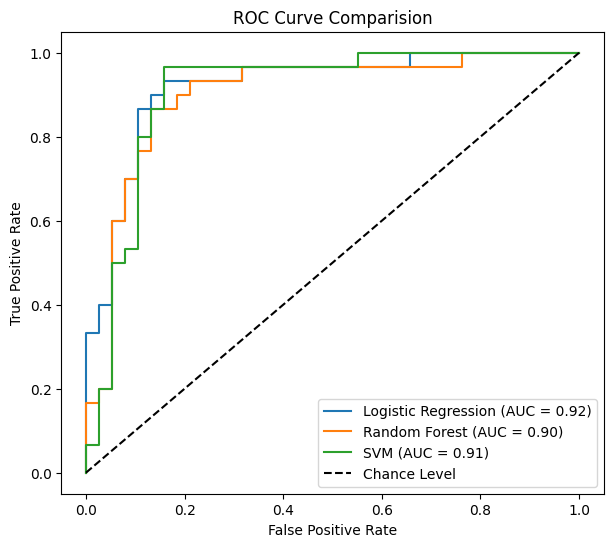

In [27]:
results =[]
results.append(evaluate_model(lr,"Logistic Regression"))
results.append(evaluate_model(rf,"Random Forest"))
results.append(evaluate_model(svm,"SVM"))


benchmark = pd.DataFrame(results,columns=["Model","Accuracy","AUC","F1","MCC"])
benchmark

plt.figure(figsize=(7,6))
models ={
    "Logistic Regression": lr,
    "Random Forest":rf,
    "SVM": svm
}

for name, model in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

plt.plot([0,1],[0,1],'k--', label='Chance Level') # Added label for the diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparision")
plt.legend()
plt.show()

/tmp/ipykernel_851/3716878178.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


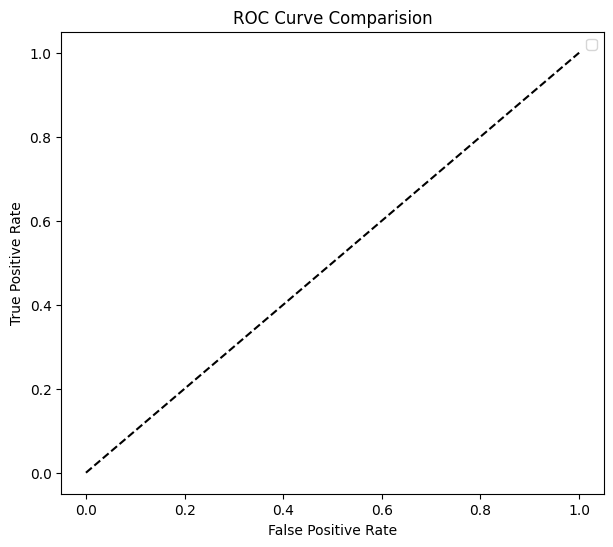

In [28]:
benchmark.sort_values(by="AUC",ascending=False)


,Model,Accuracy,AUC,F1,MCC
0,Logistic Regression,0.882353,0.920175,0.875000,0.770054
2,SVM,0.852941,0.907018,0.838710,0.705071
1,Random Forest,0.852941,0.900877,0.833333,0.701754
